# Literature-informed simulation and analysis of ADSL derived variables

## Purpose

This notebook builds a **fully synthetic clinical-trial dataset** and reproduces the key subject-level derivations discussed in the Roche ADS programming assessment:

- `AGEGR9`
- `AGEGR9N`
- `TRTSDTM`
- `TRTSTMF`
- `ITTFL`
- `ABNSBPFL`
- `LSTALVDT`
- `CARPOPFL`

It then performs quality control, descriptive analysis, adverse-event analysis, longitudinal systolic blood pressure analysis, exploratory inferential statistics, and publication-quality visualisation.

> **Important:** No participant in this notebook is real. The simulation is *literature-informed*, not a reconstruction of any Roche study. Published values are used only as calibration anchors for plausible synthetic data. Assessment-specific derivation rules are kept separate from clinical or statistical conventions.

### Clinical-programming pipeline

**Synthetic source domains (DM, EX, VS, AE, DS) → ADSL derivations → QC → descriptive analysis → visualisation → exploratory modelling**

## PubMed-indexed calibration references

The simulation uses published values as **anchors**, not as pooled estimates for a single disease population.

1. **Li C, et al.** *Sleep and risk of hypertension in general American adults: NHANES 2015–2018.* Journal of Hypertension.  
   Mean age 48.0 years, SD 17.3; 51.8% female; hypertension prevalence 32.8%.  
   PMID: **36129105**. DOI: https://doi.org/10.1097/HJH.0000000000003299

2. **Howick J, Webster R, Kirby N, Hood K.** *Rapid overview of systematic reviews of nocebo effects reported by patients taking placebos in clinical trials.* Trials. 2018;19:674.  
   Median AE prevalence in placebo groups 49.1%; median dropout due to AEs 5.0%.  
   PMID: **30526685**. DOI: https://doi.org/10.1186/s13063-018-3042-4

3. **Chacón MR, et al.** *Incidence of placebo adverse events in randomized clinical trials of targeted and immunotherapy agents in the adjuvant setting.* JAMA Network Open.  
   Pooled grade 3–4 placebo AE incidence 18%; mean discontinuation owing to placebo AEs 3.9%.  
   PMID: **30646278**. DOI: https://doi.org/10.1001/jamanetworkopen.2018.5617

4. **Swain SM, et al.** *Cardiac tolerability of pertuzumab plus trastuzumab plus docetaxel in CLEOPATRA.* The Oncologist. 2013.  
   All-grade cardiac AEs 16.4% in placebo and 14.5% in pertuzumab in that specific oncology trial.  
   PMID: **23475636**. DOI: https://doi.org/10.1634/theoncologist.2012-0448

5. **Siddiqui O.** *Statistical methods to analyze adverse events data of randomized clinical trials.* Journal of Biopharmaceutical Statistics. 2009;19:889–899.  
   PMID: **20183450**. DOI: https://doi.org/10.1080/10543400903105463

### Interpretation rule

The cardiac-AE rates above are used only as a **context-specific plausibility anchor** for software testing. The assessment rule `VSSTRESN < 100 or >= 140` is implemented because it was specified in the exercise, not because this notebook claims it is a universal clinical definition of abnormal systolic BP.

In [142]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

SEED = 20260812
rng = np.random.default_rng(SEED)

OUTPUT_DIR = Path("outputs_adsl_simulation")
FIG_DIR = OUTPUT_DIR / "figures"
DATA_DIR = OUTPUT_DIR / "data"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print(f"Random seed: {SEED}")
print(f"Outputs directory: {OUTPUT_DIR.resolve()}")

Random seed: 20260812
Outputs directory: /Users/petalc01/clinical-trial-adsl-derived-variables-analysis/outputs_adsl_simulation


In [143]:
PARAMS = {
    "n_screened": 600,
    "screen_failure_probability": 0.05,        # illustrative
    "age_mean": 48.0,                          # Li et al.
    "age_sd": 17.3,                            # Li et al.
    "female_probability": 0.518,               # Li et al.
    "baseline_hypertension_probability": 0.328,# Li et al.
    "placebo_any_ae_probability": 0.491,       # Howick et al.
    "active_any_ae_probability": 0.60,         # illustrative contrast
    "placebo_ae_dropout_probability": 0.039,   # Chacón et al.
    "active_ae_dropout_probability": 0.06,     # illustrative
    "placebo_cardiac_ae_probability": 0.164,   # Swain et al., context-specific
    "active_cardiac_ae_probability": 0.145,    # Swain et al., context-specific
    "followup_days": 180,                      # illustrative
}

benchmark_table = pd.DataFrame({
    "Quantity": [
        "Mean age, years", "Age SD, years", "Female proportion",
        "Baseline hypertension prevalence", "Placebo: any AE prevalence",
        "Placebo: dropout due to AE", "Placebo: cardiac AE prevalence",
        "Active: cardiac AE prevalence"
    ],
    "Target": [
        PARAMS["age_mean"], PARAMS["age_sd"], PARAMS["female_probability"],
        PARAMS["baseline_hypertension_probability"], PARAMS["placebo_any_ae_probability"],
        PARAMS["placebo_ae_dropout_probability"], PARAMS["placebo_cardiac_ae_probability"],
        PARAMS["active_cardiac_ae_probability"]
    ],
    "Source": [
        "Li et al., PMID 36129105", "Li et al., PMID 36129105",
        "Li et al., PMID 36129105", "Li et al., PMID 36129105",
        "Howick et al., PMID 30526685", "Chacón et al., PMID 30646278",
        "Swain et al., PMID 23475636", "Swain et al., PMID 23475636"
    ]
})
benchmark_table

,Quantity,Target,Source
0,"Mean age, years",48.000,"Li et al., PMID 36129105"
1,"Age SD, years",17.300,"Li et al., PMID 36129105"
2,Female proportion,0.518,"Li et al., PMID 36129105"
3,Baseline hypertension prevalence,0.328,"Li et al., PMID 36129105"
4,Placebo: any AE prevalence,0.491,"Howick et al., PMID 30526685"
5,Placebo: dropout due to AE,0.039,"Chacón et al., PMID 30646278"
6,Placebo: cardiac AE prevalence,0.164,"Swain et al., PMID 23475636"
7,Active: cardiac AE prevalence,0.145,"Swain et al., PMID 23475636"


## 1. Simulate source-level clinical domains

The source tables mimic common clinical-domain roles:

- **DM**: demographics and treatment arm
- **EX**: exposure
- **VS**: vital signs
- **AE**: adverse events
- **DS**: disposition

In [145]:
# DM: demographics
n = PARAMS["n_screened"]
usubjid = [f"SYN-{i:04d}" for i in range(1, n + 1)]

age = np.rint(rng.normal(PARAMS["age_mean"], PARAMS["age_sd"], n)).astype(int)
# 16-17 year olds are retained only to exercise the assessment's <18 code path.
age = np.clip(age, 16, 85)

sex = np.where(rng.random(n) < PARAMS["female_probability"], "F", "M")
screen_fail = rng.random(n) < PARAMS["screen_failure_probability"]

arm = np.full(n, None, dtype=object)
randomized_idx = np.where(~screen_fail)[0]
arm[randomized_idx] = rng.choice(["PLACEBO", "ACTIVE"], size=len(randomized_idx), p=[0.5, 0.5])

base_date = pd.Timestamp("2025-01-01")
rfstdtc = pd.Series(pd.NaT, index=np.arange(n), dtype="datetime64[ns]")
rfstdtc.loc[randomized_idx] = base_date + pd.to_timedelta(
    rng.integers(0, 181, len(randomized_idx)), unit="D"
)

dm = pd.DataFrame({
    "STUDYID": "SYNTH-ADSL-001",
    "USUBJID": usubjid,
    "AGE": age,
    "SEX": sex,
    "ARM": arm,
    "RFSTDTC": rfstdtc,
})
dm.head()

,STUDYID,USUBJID,AGE,SEX,ARM,RFSTDTC
0,SYNTH-ADSL-001,SYN-0001,33,M,PLACEBO,2025-05-14
1,SYNTH-ADSL-001,SYN-0002,37,F,ACTIVE,2025-05-17
2,SYNTH-ADSL-001,SYN-0003,56,M,PLACEBO,2025-04-01
3,SYNTH-ADSL-001,SYN-0004,36,F,ACTIVE,2025-05-17
4,SYNTH-ADSL-001,SYN-0005,57,F,ACTIVE,2025-05-25


In [146]:
# EX: exposure with complete and partial date-times
def make_partial_datetime(date_value):
    hour = int(rng.integers(7, 18))
    minute = int(rng.integers(0, 60))
    second = int(rng.integers(0, 60))
    r = rng.random()

    if r < 0.05:
        return date_value.strftime("%Y-%m-%d")                       # full time missing
    if r < 0.07:
        return f"{date_value:%Y-%m-%d}T{hour:02d}"                  # minute+second missing
    if r < 0.10:
        return f"{date_value:%Y-%m-%d}T{hour:02d}:{minute:02d}"     # seconds missing
    return f"{date_value:%Y-%m-%d}T{hour:02d}:{minute:02d}:{second:02d}"

ex_rows = []
for row in dm.loc[dm["ARM"].notna()].itertuples():
    start_date = pd.Timestamp(row.RFSTDTC) + pd.Timedelta(days=int(rng.integers(0, 3)))

    # Deliberate invalid zero-dose active record in a small subset.
    if row.ARM == "ACTIVE" and rng.random() < 0.06:
        ex_rows.append({
            "USUBJID": row.USUBJID, "EXTRT": "ACTIVE DRUG", "EXDOSE": 0.0,
            "EXSTDTC": make_partial_datetime(start_date - pd.Timedelta(days=1))
        })

    for k in range(int(rng.integers(1, 4))):
        d = start_date + pd.Timedelta(days=28 * k)
        ex_rows.append({
            "USUBJID": row.USUBJID,
            "EXTRT": "PLACEBO" if row.ARM == "PLACEBO" else "ACTIVE DRUG",
            "EXDOSE": 0.0 if row.ARM == "PLACEBO" else 100.0,
            "EXSTDTC": make_partial_datetime(d),
        })

ex = pd.DataFrame(ex_rows)
ex.head(10)

,USUBJID,EXTRT,EXDOSE,EXSTDTC
0,SYN-0001,PLACEBO,0.0,2025-05-14T11:43:12
1,SYN-0001,PLACEBO,0.0,2025-06-11T08:03:31
2,SYN-0001,PLACEBO,0.0,2025-07-09T11:30:17
3,SYN-0002,ACTIVE DRUG,100.0,2025-05-18T07:01:21
4,SYN-0002,ACTIVE DRUG,100.0,2025-06-15T07:05:57
5,SYN-0003,PLACEBO,0.0,2025-04-03T14:39:54
6,SYN-0004,ACTIVE DRUG,100.0,2025-05-17T10:18:52
7,SYN-0005,ACTIVE DRUG,100.0,2025-05-27T09:08:53
8,SYN-0006,ACTIVE DRUG,100.0,2025-06-25T16:17:17
9,SYN-0007,ACTIVE DRUG,100.0,2025-04-30T11:20:31


In [147]:
# VS: repeated systolic blood pressure
bp_state = {}
vs_rows = []
visit_days = [0, 28, 56, 84, 168]
visit_labels = ["BASELINE", "WEEK 4", "WEEK 8", "WEEK 12", "WEEK 24"]

for row in dm.loc[dm["ARM"].notna()].itertuples():
    hypertensive = bool(rng.random() < PARAMS["baseline_hypertension_probability"])
    bp_state[row.USUBJID] = hypertensive
    subject_center = rng.normal(151, 7) if hypertensive else rng.normal(122, 9)

    for day, visit in zip(visit_days, visit_labels):
        sbp = subject_center + rng.normal(0, 6) - 0.015 * day
        if rng.random() < 0.015:
            sbp = rng.normal(93, 4)

        vs_rows.append({
            "USUBJID": row.USUBJID, "VISIT": visit, "VSTESTCD": "SYSBP",
            "VSSTRESN": round(float(sbp), 1), "VSSTRESU": "mmHg",
            "VSDTC": pd.Timestamp(row.RFSTDTC) + pd.Timedelta(days=day)
        })

vs = pd.DataFrame(vs_rows)
vs.head()

,USUBJID,VISIT,VSTESTCD,VSSTRESN,VSSTRESU,VSDTC
0,SYN-0001,BASELINE,SYSBP,105.0,mmHg,2025-05-14
1,SYN-0001,WEEK 4,SYSBP,113.9,mmHg,2025-06-11
2,SYN-0001,WEEK 8,SYSBP,112.0,mmHg,2025-07-09
3,SYN-0001,WEEK 12,SYSBP,106.3,mmHg,2025-08-06
4,SYN-0001,WEEK 24,SYSBP,112.7,mmHg,2025-10-29


In [148]:
# AE: adverse events
soc_terms = {
    "CARDIAC DISORDERS": ["Palpitations", "Tachycardia", "Atrial fibrillation"],
    "NERVOUS SYSTEM DISORDERS": ["Headache", "Dizziness"],
    "GASTROINTESTINAL DISORDERS": ["Nausea", "Diarrhea"],
    "GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS": ["Fatigue"],
    "MUSCULOSKELETAL AND CONNECTIVE TISSUE DISORDERS": ["Myalgia"],
    "SKIN AND SUBCUTANEOUS TISSUE DISORDERS": ["Rash"],
}
noncardiac_socs = [s for s in soc_terms if s != "CARDIAC DISORDERS"]

ae_rows = []
subject_ae_status = {}

for row in dm.loc[dm["ARM"].notna()].itertuples():
    if row.ARM == "PLACEBO":
        target_any = PARAMS["placebo_any_ae_probability"]
        target_cardiac = PARAMS["placebo_cardiac_ae_probability"]
    else:
        target_any = PARAMS["active_any_ae_probability"]
        target_cardiac = PARAMS["active_cardiac_ae_probability"]

    has_cardiac = bool(rng.random() < target_cardiac)
    p_other = max(0.0, min(1.0, (target_any - target_cardiac) / (1 - target_cardiac)))
    has_any = has_cardiac or bool(rng.random() < p_other)
    subject_ae_status[row.USUBJID] = {"has_any": has_any, "has_cardiac": has_cardiac}

    if not has_any:
        continue

    n_events = int(1 + rng.poisson(1.1))
    cardiac_slot = int(rng.integers(0, n_events)) if has_cardiac else None

    for j in range(n_events):
        soc = "CARDIAC DISORDERS" if j == cardiac_slot else rng.choice(noncardiac_socs)
        term = rng.choice(soc_terms[soc])
        sev = rng.choice(["MILD", "MODERATE", "SEVERE"], p=[0.56, 0.34, 0.10])
        start_day = int(rng.integers(1, PARAMS["followup_days"] + 1))
        duration = int(rng.integers(1, 15))

        ae_rows.append({
            "USUBJID": row.USUBJID, "AESOC": soc, "AETERM": term, "AESEV": sev,
            "AEREL": rng.choice(
                ["RELATED", "NOT RELATED"],
                p=[0.35, 0.65] if row.ARM == "ACTIVE" else [0.15, 0.85]
            ),
            "AESTDTC": pd.Timestamp(row.RFSTDTC) + pd.Timedelta(days=start_day),
            "AEENDTC": pd.Timestamp(row.RFSTDTC) + pd.Timedelta(days=start_day + duration),
        })

ae = pd.DataFrame(ae_rows)
ae.head()

,USUBJID,AESOC,AETERM,AESEV,AEREL,AESTDTC,AEENDTC
0,SYN-0001,GENERAL DISORDERS AND ADMINISTRATION SITE COND...,Fatigue,MODERATE,NOT RELATED,2025-07-10,2025-07-20
1,SYN-0002,GASTROINTESTINAL DISORDERS,Nausea,SEVERE,RELATED,2025-07-09,2025-07-20
2,SYN-0003,MUSCULOSKELETAL AND CONNECTIVE TISSUE DISORDERS,Myalgia,MILD,NOT RELATED,2025-07-30,2025-08-12
3,SYN-0003,SKIN AND SUBCUTANEOUS TISSUE DISORDERS,Rash,MILD,NOT RELATED,2025-09-24,2025-10-08
4,SYN-0003,MUSCULOSKELETAL AND CONNECTIVE TISSUE DISORDERS,Myalgia,MILD,RELATED,2025-07-12,2025-07-19


In [149]:
# DS: disposition
ds_rows = []

for row in dm.itertuples():
    if pd.isna(row.ARM):
        ds_rows.append({
            "USUBJID": row.USUBJID,
            "DSDECOD": "SCREEN FAILURE",
            "DSDTC": base_date + pd.Timedelta(days=int(rng.integers(0, 181)))
        })
        continue

    ds_rows.append({
        "USUBJID": row.USUBJID, "DSDECOD": "RANDOMIZED", "DSDTC": pd.Timestamp(row.RFSTDTC)
    })

    has_any_ae = subject_ae_status[row.USUBJID]["has_any"]
    target_dropout = (
        PARAMS["placebo_ae_dropout_probability"]
        if row.ARM == "PLACEBO" else PARAMS["active_ae_dropout_probability"]
    )
    target_any = (
        PARAMS["placebo_any_ae_probability"]
        if row.ARM == "PLACEBO" else PARAMS["active_any_ae_probability"]
    )
    p_ae_disc_given_ae = min(1.0, target_dropout / max(target_any, 1e-8))
    ae_disc = has_any_ae and (rng.random() < p_ae_disc_given_ae)

    if ae_disc:
        final_term = "ADVERSE EVENT"
        final_day = int(rng.integers(20, 170))
    else:
        r = rng.random()
        if r < 0.015:
            final_term = "DEATH"
            final_day = int(rng.integers(30, 181))
        elif r < 0.065:
            final_term = "WITHDRAWAL BY SUBJECT"
            final_day = int(rng.integers(20, 171))
        else:
            final_term = "COMPLETED"
            final_day = PARAMS["followup_days"]

    ds_rows.append({
        "USUBJID": row.USUBJID,
        "DSDECOD": final_term,
        "DSDTC": pd.Timestamp(row.RFSTDTC) + pd.Timedelta(days=final_day)
    })

ds = pd.DataFrame(ds_rows)
ds.head(10)

,USUBJID,DSDECOD,DSDTC
0,SYN-0001,RANDOMIZED,2025-05-14
1,SYN-0001,COMPLETED,2025-11-10
2,SYN-0002,RANDOMIZED,2025-05-17
3,SYN-0002,COMPLETED,2025-11-13
4,SYN-0003,RANDOMIZED,2025-04-01
5,SYN-0003,ADVERSE EVENT,2025-05-30
6,SYN-0004,RANDOMIZED,2025-05-17
7,SYN-0004,WITHDRAWAL BY SUBJECT,2025-06-18
8,SYN-0005,RANDOMIZED,2025-05-25
9,SYN-0005,COMPLETED,2025-11-21


In [150]:
for name, df in {"dm": dm, "ex": ex, "vs": vs, "ae": ae, "ds": ds}.items():
    df.to_csv(DATA_DIR / f"{name}.csv", index=False)

print("Synthetic source dataset dimensions")
for name, df in {"DM": dm, "EX": ex, "VS": vs, "AE": ae, "DS": ds}.items():
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")

Synthetic source dataset dimensions
DM: 600 rows x 6 columns
EX: 1,172 rows x 4 columns
VS: 2,895 rows x 6 columns
AE: 614 rows x 7 columns
DS: 1,179 rows x 3 columns


## 2. Derive the ADSL variables

### Assessment rules implemented

- `AGEGR9`: `<18`, `18 - 50`, `>50`
- `AGEGR9N`: `1`, `2`, `3`
- `TRTSDTM`: earliest valid exposure where `EXDOSE > 0` or `EXDOSE == 0` with placebo
- `TRTSTMF`: preserves time-imputation provenance
- `ITTFL`: `"Y"` when `DM.ARM` is populated, `"N"` otherwise
- `ABNSBPFL`: `"Y"` if any `SYSBP` in mmHg is `<100` or `>=140`, otherwise `"N"`
- `LSTALVDT`: maximum available qualifying date from VS, AE, DS, EX
- `CARPOPFL`: `"Y"` for any AE with `AESOC == "CARDIAC DISORDERS"`, otherwise missing

In [152]:
def parse_and_impute_exstdtc(value):
    s = str(value)

    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", s):
        return pd.to_datetime(s + "T00:00:00"), "HMS"
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}T\d{2}", s):
        return pd.to_datetime(s + ":00:00"), "MS"
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}", s):
        return pd.to_datetime(s + ":00"), ""
    return pd.to_datetime(s), ""

ex_work = ex.copy()
parsed = ex_work["EXSTDTC"].apply(parse_and_impute_exstdtc)
ex_work["EXSTDTC_PARSED"] = [x[0] for x in parsed]
ex_work["TRTSTMF_CANDIDATE"] = [x[1] for x in parsed]

valid_ex = ex_work[
    (ex_work["EXDOSE"] > 0) |
    ((ex_work["EXDOSE"] == 0) & ex_work["EXTRT"].str.contains("PLACEBO", case=False, na=False))
].copy()

first_ex = (
    valid_ex.sort_values(["USUBJID", "EXSTDTC_PARSED"])
    .groupby("USUBJID", as_index=False)
    .first()[["USUBJID", "EXSTDTC_PARSED", "TRTSTMF_CANDIDATE"]]
    .rename(columns={"EXSTDTC_PARSED": "TRTSDTM", "TRTSTMF_CANDIDATE": "TRTSTMF"})
)

adsl = dm.copy()

adsl["AGEGR9"] = pd.cut(
    adsl["AGE"], bins=[-np.inf, 17, 50, np.inf],
    labels=["<18", "18 - 50", ">50"], right=True
)
adsl["AGEGR9N"] = (
    adsl["AGEGR9"].astype(str)
    .map({"<18": 1, "18 - 50": 2, ">50": 3})
    .astype("Int64")
)

adsl = adsl.merge(first_ex, on="USUBJID", how="left")
adsl["ITTFL"] = np.where(adsl["ARM"].notna(), "Y", "N")

vs_sys = vs[(vs["VSTESTCD"] == "SYSBP") & (vs["VSSTRESU"] == "mmHg")].copy()
abn_bp_subjects = set(
    vs_sys.loc[(vs_sys["VSSTRESN"] < 100) | (vs_sys["VSSTRESN"] >= 140), "USUBJID"]
)
adsl["ABNSBPFL"] = np.where(adsl["USUBJID"].isin(abn_bp_subjects), "Y", "N")

cardiac_subjects = set(
    ae.loc[ae["AESOC"].str.upper().eq("CARDIAC DISORDERS"), "USUBJID"]
)
adsl["CARPOPFL"] = np.where(adsl["USUBJID"].isin(cardiac_subjects), "Y", pd.NA)

last_vs = vs.groupby("USUBJID")["VSDTC"].max().rename("LAST_VS_DATE")
last_ae = ae.groupby("USUBJID")["AESTDTC"].max().rename("LAST_AE_DATE")
last_ds = ds.groupby("USUBJID")["DSDTC"].max().rename("LAST_DS_DATE")
last_ex = ex_work.groupby("USUBJID")["EXSTDTC_PARSED"].max().rename("LAST_EX_DATE")

last_dates = pd.concat([last_vs, last_ae, last_ds, last_ex], axis=1)
last_dates["LSTALVDT"] = last_dates.max(axis=1)
adsl = adsl.merge(last_dates[["LSTALVDT"]], left_on="USUBJID", right_index=True, how="left")

core_cols = [
    "STUDYID", "USUBJID", "AGE", "SEX", "ARM", "RFSTDTC",
    "AGEGR9", "AGEGR9N", "TRTSDTM", "TRTSTMF", "ITTFL",
    "ABNSBPFL", "LSTALVDT", "CARPOPFL"
]
adsl = adsl[core_cols].sort_values("USUBJID").reset_index(drop=True)
adsl.to_csv(DATA_DIR / "adsl.csv", index=False)

adsl.head(12)

,STUDYID,USUBJID,AGE,SEX,ARM,RFSTDTC,AGEGR9,AGEGR9N,TRTSDTM,TRTSTMF,ITTFL,ABNSBPFL,LSTALVDT,CARPOPFL
0,SYNTH-ADSL-001,SYN-0001,33,M,PLACEBO,2025-05-14,18 - 50,2,2025-05-14 11:43:12,,Y,N,2025-11-10,NaN
1,SYNTH-ADSL-001,SYN-0002,37,F,ACTIVE,2025-05-17,18 - 50,2,2025-05-18 07:01:21,,Y,N,2025-11-13,NaN
2,SYNTH-ADSL-001,SYN-0003,56,M,PLACEBO,2025-04-01,>50,3,2025-04-03 14:39:54,,Y,Y,2025-09-24,NaN
3,SYNTH-ADSL-001,SYN-0004,36,F,ACTIVE,2025-05-17,18 - 50,2,2025-05-17 10:18:52,,Y,N,2025-11-01,NaN
4,SYNTH-ADSL-001,SYN-0005,57,F,ACTIVE,2025-05-25,>50,3,2025-05-27 09:08:53,,Y,N,2025-11-21,NaN
5,SYNTH-ADSL-001,SYN-0006,58,M,ACTIVE,2025-06-24,>50,3,2025-06-25 16:17:17,,Y,N,2025-12-21,NaN
6,SYNTH-ADSL-001,SYN-0007,60,F,ACTIVE,2025-04-29,>50,3,2025-04-30 11:20:31,,Y,Y,2025-10-14,NaN
7,SYNTH-ADSL-001,SYN-0008,52,F,ACTIVE,2025-06-14,>50,3,2025-06-15 09:41:32,,Y,Y,2025-12-11,NaN
8,SYNTH-ADSL-001,SYN-0009,44,M,ACTIVE,2025-01-14,18 - 50,2,2025-01-16 10:52:26,,Y,Y,2025-07-01,NaN
9,SYNTH-ADSL-001,SYN-0010,21,F,PLACEBO,2025-06-15,18 - 50,2,2025-06-15 14:15:00,,Y,Y,2025-12-12,NaN


## 3. Independent QC and traceability checks

The notebook treats **execution** and **validation** as separate tasks. The checks below independently reproduce key rules from the source domains.

In [154]:
qc = []

def add_qc(check, passed, detail):
    qc.append({"Check": check, "Pass": bool(passed), "Detail": detail})

add_qc(
    "ADSL one record per subject",
    adsl["USUBJID"].is_unique,
    f"{adsl['USUBJID'].nunique()} unique IDs in {len(adsl)} rows"
)

age_rule_ok = (
    ((adsl["AGE"] < 18) & (adsl["AGEGR9"].astype(str) == "<18") & (adsl["AGEGR9N"] == 1)) |
    ((adsl["AGE"].between(18, 50)) & (adsl["AGEGR9"].astype(str) == "18 - 50") & (adsl["AGEGR9N"] == 2)) |
    ((adsl["AGE"] > 50) & (adsl["AGEGR9"].astype(str) == ">50") & (adsl["AGEGR9N"] == 3))
).all()
add_qc("AGEGR9/AGEGR9N match AGE", age_rule_ok, "All subjects evaluated")

itt_ok = (
    ((adsl["ARM"].notna()) & (adsl["ITTFL"] == "Y")) |
    ((adsl["ARM"].isna()) & (adsl["ITTFL"] == "N"))
).all()
add_qc("ITTFL matches ARM rule", itt_ok, "ARM populated -> Y")

trt_screen_ok = adsl.loc[adsl["ITTFL"] == "N", "TRTSDTM"].isna().all()
add_qc("Non-ITT subjects have no TRTSDTM", trt_screen_ok, "Screen failures checked")

independent_abn = (
    vs_sys.assign(_abn=(vs_sys["VSSTRESN"] < 100) | (vs_sys["VSSTRESN"] >= 140))
    .groupby("USUBJID")["_abn"].any()
)
expected_abn = adsl["USUBJID"].map(independent_abn).fillna(False)
abn_ok = np.array_equal(np.where(expected_abn, "Y", "N"), adsl["ABNSBPFL"].to_numpy())
add_qc("ABNSBPFL independently reproduced", abn_ok, "<100 or >=140 mmHg")

expected_cardiac = adsl["USUBJID"].isin(cardiac_subjects)
car_ok = (
    ((expected_cardiac) & adsl["CARPOPFL"].eq("Y").fillna(False)) |
    ((~expected_cardiac) & adsl["CARPOPFL"].isna())
).all()
add_qc("CARPOPFL independently reproduced", car_ok, "AESOC == CARDIAC DISORDERS")

expected_lstalv = adsl["USUBJID"].map(last_dates["LSTALVDT"])
lsta_ok = (
    pd.to_datetime(adsl["LSTALVDT"]).reset_index(drop=True) ==
    pd.to_datetime(expected_lstalv).reset_index(drop=True)
).all()
add_qc("LSTALVDT equals source-date maximum", lsta_ok, "VS/AE/DS/EX reconciled")

qc_df = pd.DataFrame(qc)
qc_df

,Check,Pass,Detail
0,ADSL one record per subject,True,600 unique IDs in 600 rows
1,AGEGR9/AGEGR9N match AGE,True,All subjects evaluated
2,ITTFL matches ARM rule,True,ARM populated -> Y
3,Non-ITT subjects have no TRTSDTM,True,Screen failures checked
4,ABNSBPFL independently reproduced,True,<100 or >=140 mmHg
5,CARPOPFL independently reproduced,True,AESOC == CARDIAC DISORDERS
6,LSTALVDT equals source-date maximum,True,VS/AE/DS/EX reconciled


In [155]:
if not qc_df["Pass"].all():
    raise AssertionError("At least one QC check failed.")
print("All programmed QC checks passed.")

All programmed QC checks passed.


## 4. Cohort summary and benchmark calibration

In [157]:
rand = adsl[adsl["ITTFL"] == "Y"].copy()
placebo_ids = set(rand.loc[rand["ARM"] == "PLACEBO", "USUBJID"])
active_ids = set(rand.loc[rand["ARM"] == "ACTIVE", "USUBJID"])

baseline_vs = vs[vs["VISIT"] == "BASELINE"].copy()
baseline_htn_observed = (baseline_vs["VSSTRESN"] >= 140).mean()

placebo_any_ae_observed = len(placebo_ids & set(ae["USUBJID"])) / len(placebo_ids)

final_ds = (
    ds[ds["DSDECOD"] != "RANDOMIZED"]
    .sort_values(["USUBJID", "DSDTC"])
    .groupby("USUBJID", as_index=False)
    .tail(1)
)
placebo_ae_dropout_observed = (
    final_ds["USUBJID"].isin(placebo_ids) & final_ds["DSDECOD"].eq("ADVERSE EVENT")
).sum() / len(placebo_ids)

placebo_cardiac_observed = len(placebo_ids & cardiac_subjects) / len(placebo_ids)
active_cardiac_observed = len(active_ids & cardiac_subjects) / len(active_ids)

observed_benchmarks = pd.DataFrame({
    "Quantity": [
        "Mean age, years", "Age SD, years", "Female proportion",
        "Baseline SBP >=140 prevalence", "Placebo: any AE prevalence",
        "Placebo: dropout due to AE", "Placebo: cardiac AE prevalence",
        "Active: cardiac AE prevalence"
    ],
    "Target": [
        PARAMS["age_mean"], PARAMS["age_sd"], PARAMS["female_probability"],
        PARAMS["baseline_hypertension_probability"], PARAMS["placebo_any_ae_probability"],
        PARAMS["placebo_ae_dropout_probability"], PARAMS["placebo_cardiac_ae_probability"],
        PARAMS["active_cardiac_ae_probability"]
    ],
    "Observed": [
        dm["AGE"].mean(), dm["AGE"].std(ddof=1), (dm["SEX"] == "F").mean(),
        baseline_htn_observed, placebo_any_ae_observed, placebo_ae_dropout_observed,
        placebo_cardiac_observed, active_cardiac_observed
    ]
})
observed_benchmarks["Difference"] = observed_benchmarks["Observed"] - observed_benchmarks["Target"]
observed_benchmarks

,Quantity,Target,Observed,Difference
0,"Mean age, years",48.000,48.866667,0.866667
1,"Age SD, years",17.300,16.282017,-1.017983
2,Female proportion,0.518,0.528333,0.010333
3,Baseline SBP >=140 prevalence,0.328,0.331606,0.003606
4,Placebo: any AE prevalence,0.491,0.494881,0.003881
5,Placebo: dropout due to AE,0.039,0.037543,-0.001457
6,Placebo: cardiac AE prevalence,0.164,0.150171,-0.013829
7,Active: cardiac AE prevalence,0.145,0.115385,-0.029615


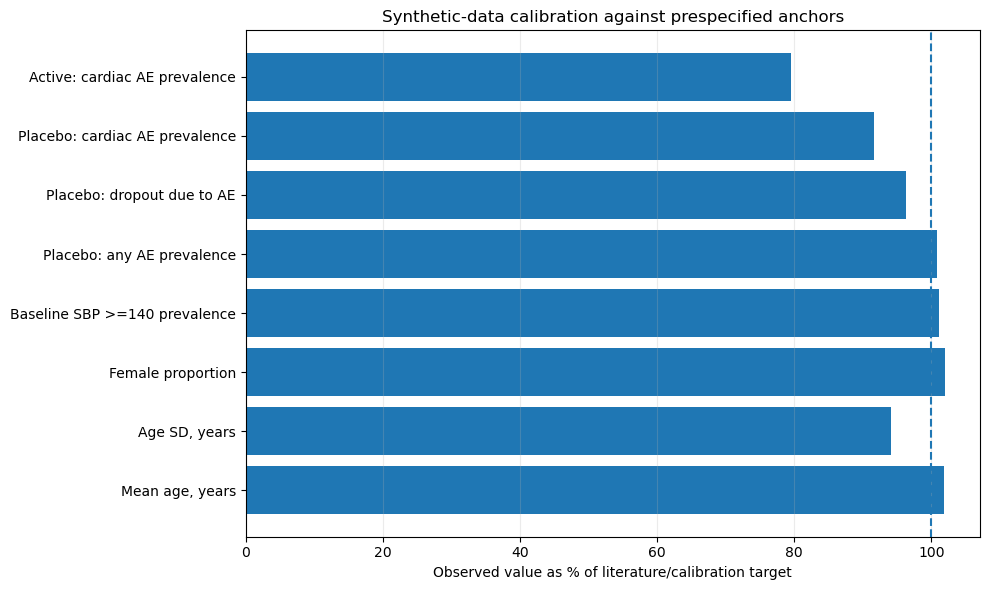

In [158]:
plot_df = observed_benchmarks.copy()
plot_df["Observed / target (%)"] = 100 * plot_df["Observed"] / plot_df["Target"]

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(plot_df))
ax.barh(y, plot_df["Observed / target (%)"])
ax.axvline(100, linestyle="--", linewidth=1.5)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["Quantity"])
ax.set_xlabel("Observed value as % of literature/calibration target")
ax.set_title("Synthetic-data calibration against prespecified anchors")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_benchmark_calibration.png", dpi=300, bbox_inches="tight")
plt.show()

In [159]:
max_rel_dev = (
    (observed_benchmarks["Observed"] - observed_benchmarks["Target"]).abs()
    / observed_benchmarks["Target"].replace(0, np.nan)
).max()

print("INTERPRETATION")
print(f"- Largest relative deviation from a calibration target: {max_rel_dev*100:.1f}%.")
print("- Finite-sample deviations are expected in stochastic simulation.")
print("- Agreement with anchors is a simulation check, not external clinical validation.")

INTERPRETATION
- Largest relative deviation from a calibration target: 20.4%.
- Finite-sample deviations are expected in stochastic simulation.
- Agreement with anchors is a simulation check, not external clinical validation.


In [160]:
def n_pct(series, value):
    n = (series == value).sum()
    return f"{n} ({100*n/len(series):.1f}%)"

summary_rows = []
for arm_name, g in rand.groupby("ARM"):
    summary_rows.append({
        "ARM": arm_name,
        "N": len(g),
        "Age mean (SD)": f"{g['AGE'].mean():.1f} ({g['AGE'].std(ddof=1):.1f})",
        "Female n (%)": n_pct(g["SEX"], "F"),
        "<18 n (%)": n_pct(g["AGEGR9"].astype(str), "<18"),
        "18-50 n (%)": n_pct(g["AGEGR9"].astype(str), "18 - 50"),
        ">50 n (%)": n_pct(g["AGEGR9"].astype(str), ">50"),
        "ABNSBPFL=Y n (%)": n_pct(g["ABNSBPFL"], "Y"),
        "CARPOPFL=Y n (%)": f"{g['CARPOPFL'].eq('Y').sum()} ({100*g['CARPOPFL'].eq('Y').mean():.1f}%)",
        "TRT time imputed n (%)": f"{g['TRTSTMF'].fillna('').ne('').sum()} ({100*g['TRTSTMF'].fillna('').ne('').mean():.1f}%)"
    })

table1 = pd.DataFrame(summary_rows)
table1

,ARM,N,Age mean (SD),Female n (%),<18 n (%),18-50 n (%),>50 n (%),ABNSBPFL=Y n (%),CARPOPFL=Y n (%),TRT time imputed n (%)
0,ACTIVE,286,48.6 (16.0),151 (52.8%),8 (2.8%),148 (51.7%),130 (45.5%),144 (50.3%),33 (11.5%),22 (7.7%)
1,PLACEBO,293,49.3 (16.7),152 (51.9%),12 (4.1%),139 (47.4%),142 (48.5%),146 (49.8%),44 (15.0%),29 (9.9%)


## 5. Age distribution and age-group derivation

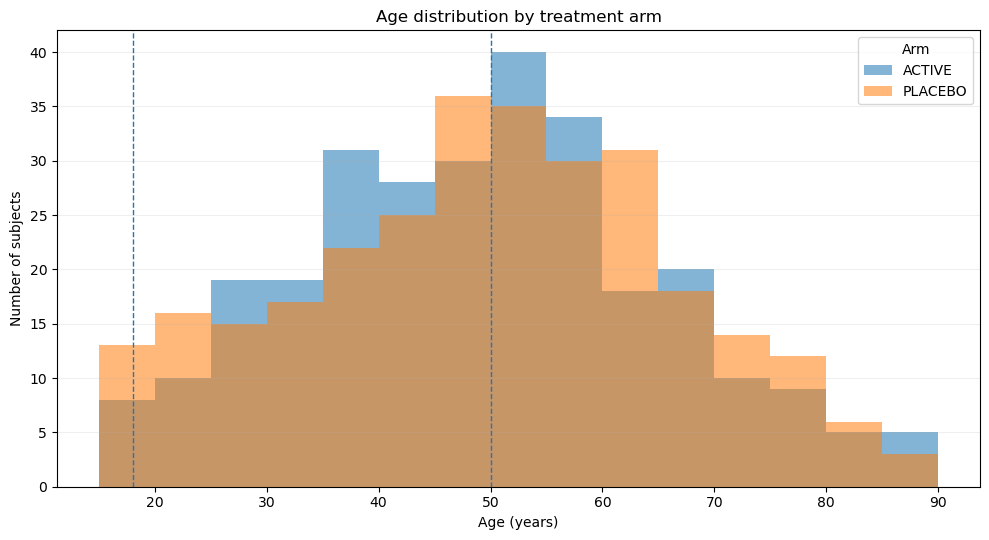

In [162]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.arange(15, 91, 5)

for arm_name, g in rand.groupby("ARM"):
    ax.hist(g["AGE"], bins=bins, alpha=0.55, label=arm_name)

ax.axvline(18, linestyle="--", linewidth=1)
ax.axvline(50, linestyle="--", linewidth=1)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of subjects")
ax.set_title("Age distribution by treatment arm")
ax.legend(title="Arm")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [163]:
age_counts = pd.crosstab(rand["AGEGR9"], rand["ARM"], margins=True)
print(age_counts)
print("\nINTERPRETATION")
print("- AGEGR9 converts continuous age into prespecified analysis categories.")
print("- AGEGR9N is a numeric code for the category, not a continuous biological measurement.")
print("- The <18 stratum is included as a deliberate software edge case.")

ARM      ACTIVE  PLACEBO  All
AGEGR9                       
<18           8       12   20
18 - 50     148      139  287
>50         130      142  272
All         286      293  579

INTERPRETATION
- AGEGR9 converts continuous age into prespecified analysis categories.
- AGEGR9N is a numeric code for the category, not a continuous biological measurement.
- The <18 stratum is included as a deliberate software edge case.


## 6. Treatment start and time imputation

In [165]:
imputation_summary = (
    rand.assign(
        Imputation=rand["TRTSTMF"].fillna("").replace({
            "": "None / seconds only",
            "HMS": "Hour+minute+second imputed",
            "MS": "Minute+second imputed"
        })
    )
    .groupby(["ARM", "Imputation"])
    .size()
    .rename("N")
    .reset_index()
)
imputation_summary["Percent_within_arm"] = (
    imputation_summary["N"] /
    imputation_summary.groupby("ARM")["N"].transform("sum") * 100
)
imputation_summary

,ARM,Imputation,N,Percent_within_arm
0,ACTIVE,Hour+minute+second imputed,15,5.244755
1,ACTIVE,Minute+second imputed,7,2.447552
2,ACTIVE,None / seconds only,264,92.307692
3,PLACEBO,Hour+minute+second imputed,19,6.484642
4,PLACEBO,Minute+second imputed,10,3.412969
5,PLACEBO,None / seconds only,264,90.102389


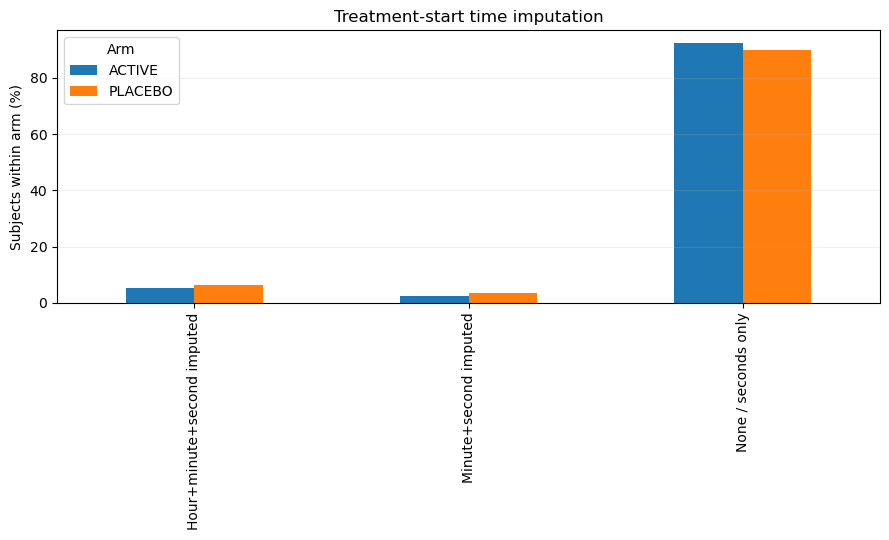

In [166]:
pivot_imp = imputation_summary.pivot(
    index="Imputation", columns="ARM", values="Percent_within_arm"
).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5.5))
pivot_imp.plot(kind="bar", ax=ax)
ax.set_ylabel("Subjects within arm (%)")
ax.set_xlabel("")
ax.set_title("Treatment-start time imputation")
ax.legend(title="Arm")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_time_imputation.png", dpi=300, bbox_inches="tight")
plt.show()

In [167]:
print("INTERPRETATION")
print("- TRTSDTM is selected only from valid exposure records.")
print("- Placebo with EXDOSE=0 remains valid when EXTRT identifies placebo.")
print("- TRTSTMF keeps imputed time components transparent.")
print("- Exact imputation flag conventions must follow the production specification.")

INTERPRETATION
- TRTSDTM is selected only from valid exposure records.
- Placebo with EXDOSE=0 remains valid when EXTRT identifies placebo.
- TRTSTMF keeps imputed time components transparent.
- Exact imputation flag conventions must follow the production specification.


## 7. Longitudinal systolic blood pressure and `ABNSBPFL`

In [169]:
vs_arm = vs.merge(rand[["USUBJID", "ARM", "AGEGR9"]], on="USUBJID", how="inner")
visit_order = {v: i for i, v in enumerate(visit_labels)}
vs_arm["VISIT_ORDER"] = vs_arm["VISIT"].map(visit_order)

sbp_summary = (
    vs_arm.groupby(["ARM", "VISIT_ORDER", "VISIT"])["VSSTRESN"]
    .agg(["count", "mean", "std"])
    .reset_index()
)
sbp_summary["se"] = sbp_summary["std"] / np.sqrt(sbp_summary["count"])
sbp_summary["lower"] = sbp_summary["mean"] - 1.96 * sbp_summary["se"]
sbp_summary["upper"] = sbp_summary["mean"] + 1.96 * sbp_summary["se"]
sbp_summary

,ARM,VISIT_ORDER,VISIT,count,mean,std,se,lower,upper
0,ACTIVE,0,BASELINE,286,131.852448,17.821095,1.053783,129.787032,133.917863
1,ACTIVE,1,WEEK 4,286,131.423776,18.124598,1.071730,129.323186,133.524367
2,ACTIVE,2,WEEK 8,286,131.455245,17.951581,1.061499,129.374706,133.535783
3,ACTIVE,3,WEEK 12,286,130.396853,18.408492,1.088517,128.263360,132.530346
4,ACTIVE,4,WEEK 24,286,130.189510,17.715299,1.047528,128.136356,132.242665
5,PLACEBO,0,BASELINE,293,131.980546,17.939126,1.048015,129.926437,134.034655
6,PLACEBO,1,WEEK 4,293,131.943686,17.186685,1.004057,129.975735,133.911637
7,PLACEBO,2,WEEK 8,293,130.959386,17.689511,1.033432,128.933858,132.984913
8,PLACEBO,3,WEEK 12,293,130.284642,17.529003,1.024055,128.277493,132.291790
9,PLACEBO,4,WEEK 24,293,130.105461,17.262503,1.008486,128.128828,132.082094


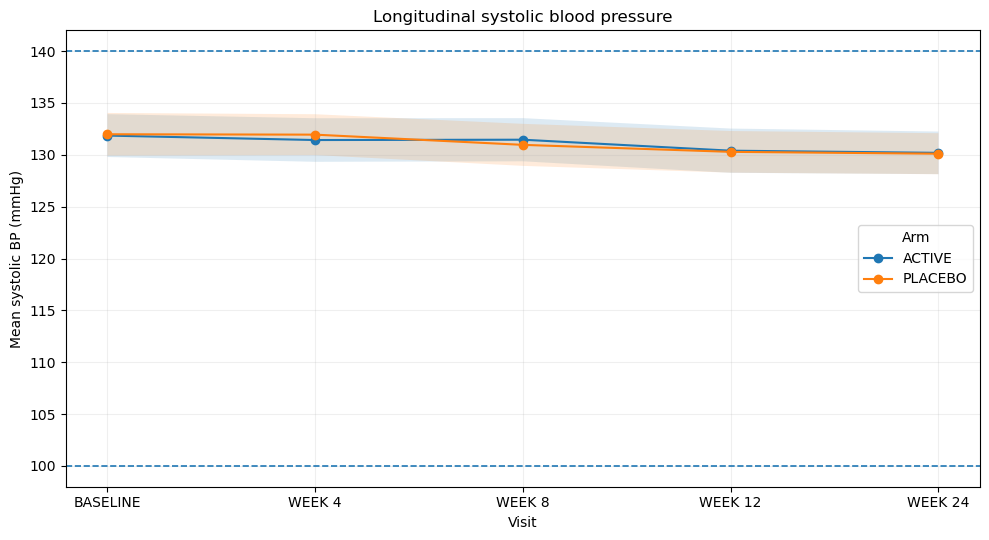

In [170]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for arm_name, g in sbp_summary.groupby("ARM"):
    g = g.sort_values("VISIT_ORDER")
    ax.plot(g["VISIT_ORDER"], g["mean"], marker="o", label=arm_name)
    ax.fill_between(g["VISIT_ORDER"], g["lower"], g["upper"], alpha=0.15)

ax.axhline(140, linestyle="--", linewidth=1.2)
ax.axhline(100, linestyle="--", linewidth=1.2)
ax.set_xticks(range(len(visit_labels)))
ax.set_xticklabels(visit_labels)
ax.set_ylabel("Mean systolic BP (mmHg)")
ax.set_xlabel("Visit")
ax.set_title("Longitudinal systolic blood pressure")
ax.legend(title="Arm")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_longitudinal_sbp.png", dpi=300, bbox_inches="tight")
plt.show()

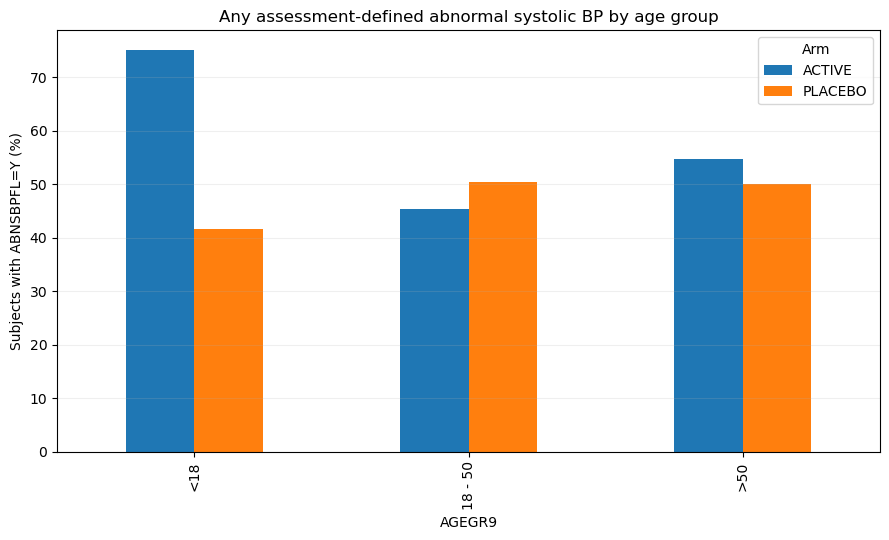

In [171]:
abn_plot = (
    rand.assign(ABN=rand["ABNSBPFL"].eq("Y").astype(int))
    .groupby(["AGEGR9", "ARM"], observed=False)["ABN"]
    .mean().mul(100).rename("Percent").reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5.5))
pivot_abn = abn_plot.pivot(index="AGEGR9", columns="ARM", values="Percent")
pivot_abn.plot(kind="bar", ax=ax)
ax.set_ylabel("Subjects with ABNSBPFL=Y (%)")
ax.set_xlabel("AGEGR9")
ax.set_title("Any assessment-defined abnormal systolic BP by age group")
ax.legend(title="Arm")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_abnormal_sbp_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

In [172]:
bp_tab = pd.crosstab(rand["ARM"], rand["ABNSBPFL"])
chi2_bp, p_bp, _, _ = stats.chi2_contingency(bp_tab)

print(bp_tab)
print(f"\nChi-square p-value: {p_bp:.4g}")
print("\nINTERPRETATION")
print("- ABNSBPFL is a subject-level flag: one qualifying value is enough to set Y.")
print("- It is not equivalent to a diagnosis of hypertension.")
print("- The threshold is implemented exactly as specified in the assessment.")
print(f"- Arm-by-ABNSBPFL association: {'detectable' if p_bp < 0.05 else 'not detectable'} at alpha=0.05.")

ABNSBPFL    N    Y
ARM               
ACTIVE    142  144
PLACEBO   147  146

Chi-square p-value: 0.9664

INTERPRETATION
- ABNSBPFL is a subject-level flag: one qualifying value is enough to set Y.
- It is not equivalent to a diagnosis of hypertension.
- The threshold is implemented exactly as specified in the assessment.
- Arm-by-ABNSBPFL association: not detectable at alpha=0.05.


## 8. Adverse events: subject incidence versus event counts

- **Event count** = number of AE records.
- **Subject incidence** = number or percentage of participants with at least one qualifying AE.

A participant can contribute multiple events but should generally contribute once to a subject-incidence denominator for a given category.

In [174]:
ae_arm = ae.merge(rand[["USUBJID", "ARM"]], on="USUBJID", how="inner")

ae_overview = []
for arm_name, g_subj in rand.groupby("ARM"):
    g_ae = ae_arm[ae_arm["ARM"] == arm_name]
    n_subjects_with_ae = g_ae["USUBJID"].nunique()
    ae_overview.append({
        "ARM": arm_name,
        "Subjects": len(g_subj),
        "Subjects with >=1 AE": n_subjects_with_ae,
        "AE subject incidence (%)": 100*n_subjects_with_ae/len(g_subj),
        "AE event records": len(g_ae),
        "Events per affected subject": len(g_ae)/n_subjects_with_ae if n_subjects_with_ae else np.nan
    })

ae_overview = pd.DataFrame(ae_overview)
ae_overview

,ARM,Subjects,Subjects with >=1 AE,AE subject incidence (%),AE event records,Events per affected subject
0,ACTIVE,286,153,53.496503,325,2.124183
1,PLACEBO,293,145,49.488055,289,1.993103


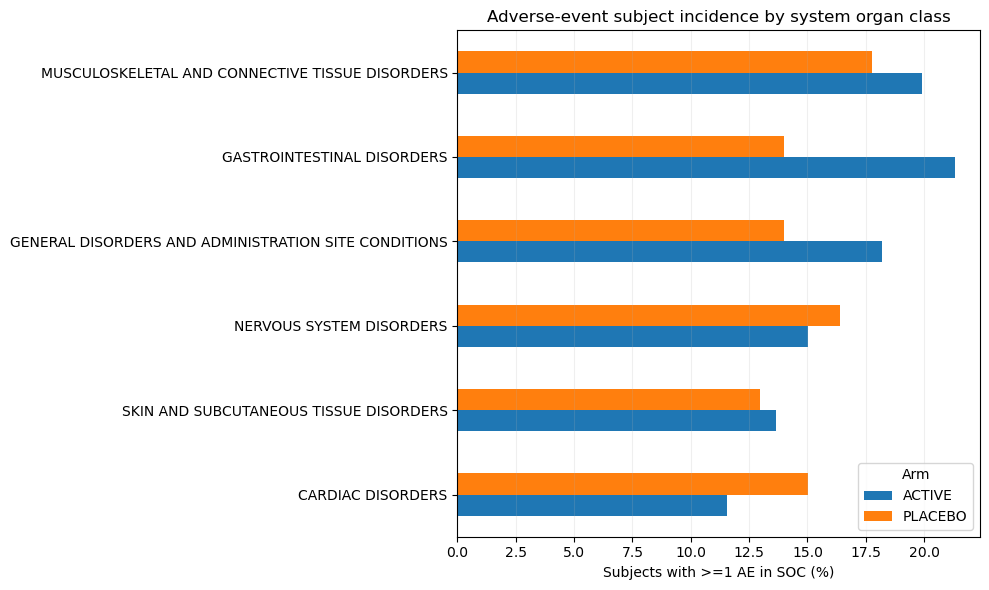

In [175]:
soc_incidence = (
    ae_arm[["USUBJID", "ARM", "AESOC"]].drop_duplicates()
    .groupby(["ARM", "AESOC"])["USUBJID"].nunique()
    .rename("N").reset_index()
)
arm_den = rand.groupby("ARM")["USUBJID"].nunique()
soc_incidence["Percent"] = soc_incidence.apply(
    lambda r: 100*r["N"]/arm_den[r["ARM"]], axis=1
)

soc_rank = soc_incidence.groupby("AESOC")["Percent"].mean().sort_values().index
pivot_soc = (
    soc_incidence.pivot(index="AESOC", columns="ARM", values="Percent")
    .reindex(soc_rank).fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_soc.plot(kind="barh", ax=ax)
ax.set_xlabel("Subjects with >=1 AE in SOC (%)")
ax.set_ylabel("")
ax.set_title("Adverse-event subject incidence by system organ class")
ax.legend(title="Arm")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_ae_soc_incidence.png", dpi=300, bbox_inches="tight")
plt.show()

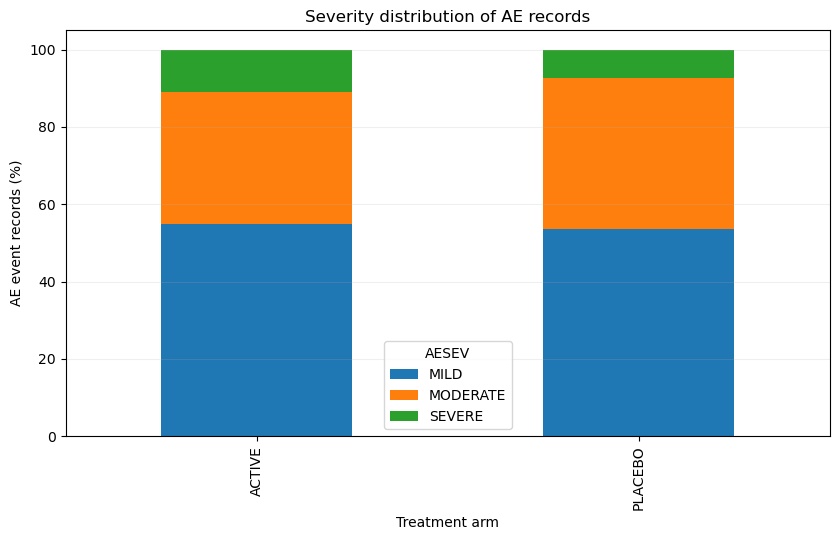

INTERPRETATION
- This figure counts AE records, not unique subjects.
- One participant may contribute several events.
- Severity (mild/moderate/severe) is not the same as regulatory seriousness.


In [176]:
sev_counts = pd.crosstab(ae_arm["ARM"], ae_arm["AESEV"])
sev_pct = sev_counts.div(sev_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sev_pct.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("AE event records (%)")
ax.set_xlabel("Treatment arm")
ax.set_title("Severity distribution of AE records")
ax.legend(title="AESEV")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_ae_severity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("INTERPRETATION")
print("- This figure counts AE records, not unique subjects.")
print("- One participant may contribute several events.")
print("- Severity (mild/moderate/severe) is not the same as regulatory seriousness.")

## 9. Cardiac AE population flag (`CARPOPFL`)

In [178]:
card_rows = []
for arm_name, g in rand.groupby("ARM"):
    n_arm = len(g)
    x = g["CARPOPFL"].eq("Y").sum()
    lo, hi = proportion_confint(x, n_arm, alpha=0.05, method="wilson")
    card_rows.append({
        "ARM": arm_name, "N": n_arm, "Cardiac AE subjects": x,
        "Incidence": x/n_arm, "Lower95": lo, "Upper95": hi
    })

card_inc = pd.DataFrame(card_rows)
card_inc

,ARM,N,Cardiac AE subjects,Incidence,Lower95,Upper95
0,ACTIVE,286,33,0.115385,0.083350,0.157614
1,PLACEBO,293,44,0.150171,0.113807,0.195588


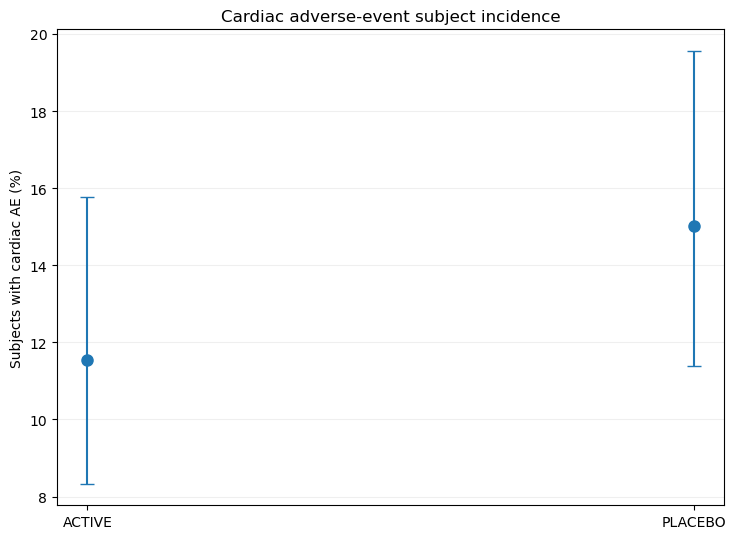

In [179]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
xpos = np.arange(len(card_inc))
y = card_inc["Incidence"] * 100
yerr = np.vstack([
    (card_inc["Incidence"] - card_inc["Lower95"]) * 100,
    (card_inc["Upper95"] - card_inc["Incidence"]) * 100
])

ax.errorbar(xpos, y, yerr=yerr, fmt="o", capsize=5, markersize=8)
ax.set_xticks(xpos)
ax.set_xticklabels(card_inc["ARM"])
ax.set_ylabel("Subjects with cardiac AE (%)")
ax.set_title("Cardiac adverse-event subject incidence")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_cardiac_ae_incidence.png", dpi=300, bbox_inches="tight")
plt.show()

In [180]:
card_test_df = rand.assign(CARDIAC=rand["CARPOPFL"].eq("Y"))
card_tab = pd.crosstab(card_test_df["ARM"], card_test_df["CARDIAC"])
chi2_card, p_card, _, _ = stats.chi2_contingency(card_tab)

print(card_tab)
print(f"\nChi-square p-value: {p_card:.4g}")
print("\nINTERPRETATION")
print("- CARPOPFL=Y means at least one AE was classified under CARDIAC DISORDERS.")
print("- Missing CARPOPFL means 'not flagged' under this assessment convention.")
print(f"- Arm difference: {'detectable' if p_card < 0.05 else 'not detectable'} in this synthetic realization.")
print("- Because cardiac-AE probabilities were prespecified, this is not an independent clinical finding.")

CARDIAC  False  True 
ARM                  
ACTIVE     253     33
PLACEBO    249     44

Chi-square p-value: 0.267

INTERPRETATION
- CARPOPFL=Y means at least one AE was classified under CARDIAC DISORDERS.
- Missing CARPOPFL means 'not flagged' under this assessment convention.
- Arm difference: not detectable in this synthetic realization.
- Because cardiac-AE probabilities were prespecified, this is not an independent clinical finding.


## 10. Last known alive date (`LSTALVDT`) and follow-up coverage

In [182]:
rand["FOLLOWUP_DAYS"] = (
    pd.to_datetime(rand["LSTALVDT"]) - pd.to_datetime(rand["RFSTDTC"])
).dt.days

followup_summary = rand.groupby("ARM")["FOLLOWUP_DAYS"].agg(
    ["count", "mean", "std", "median", "min", "max"]
)
followup_summary

,count,mean,std,median,min,max
ARM,,,,,,
ACTIVE,286,178.493007,3.917342,180.0,168,180
PLACEBO,293,178.873720,3.447417,180.0,168,180


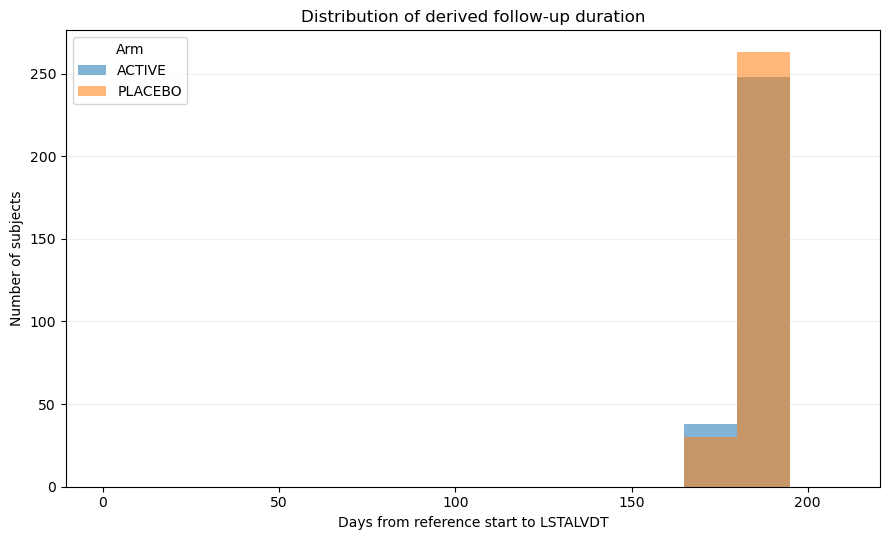

INTERPRETATION
- LSTALVDT summarizes the latest qualifying dated evidence across domains.
- It is highly traceability-sensitive: bad date parsing or joins can change the result.
- Production definitions must specify exactly which source records qualify.


In [183]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bins = np.arange(0, PARAMS["followup_days"] + 31, 15)

for arm_name, g in rand.groupby("ARM"):
    ax.hist(g["FOLLOWUP_DAYS"], bins=bins, alpha=0.55, label=arm_name)

ax.set_xlabel("Days from reference start to LSTALVDT")
ax.set_ylabel("Number of subjects")
ax.set_title("Distribution of derived follow-up duration")
ax.legend(title="Arm")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_followup_duration.png", dpi=300, bbox_inches="tight")
plt.show()

print("INTERPRETATION")
print("- LSTALVDT summarizes the latest qualifying dated evidence across domains.")
print("- It is highly traceability-sensitive: bad date parsing or joins can change the result.")
print("- Production definitions must specify exactly which source records qualify.")

## 11. Exploratory multivariable model for cardiac-AE flag

This is a **methodological demonstration only**. Synthetic odds ratios are not clinical evidence and should not be interpreted causally.

In [185]:
# Prepare clean data specifically for logistic regression
model_df = model_df.copy()

# Binary outcome and predictor
model_df["CARDIAC_BIN"] = model_df["CARPOPFL"].eq("Y").astype("int64")
model_df["ABN_BP_BIN"] = model_df["ABNSBPFL"].eq("Y").astype("int64")

# Force AGE to standard NumPy numeric dtype
model_df["AGE"] = pd.to_numeric(
    model_df["AGE"],
    errors="coerce"
).astype("float64")

# Patsy/statsmodels works reliably with ordinary Python object
# columns for categorical predictors
model_df["ARM"] = model_df["ARM"].astype("object")
model_df["SEX"] = model_df["SEX"].astype("object")

# Remove subjects missing any variable required by the model
model_df = model_df.dropna(
    subset=[
        "CARDIAC_BIN",
        "AGE",
        "ARM",
        "SEX",
        "ABN_BP_BIN"
    ]
).copy()

# Check model input types
print(model_df[
    ["CARDIAC_BIN", "AGE", "ARM", "SEX", "ABN_BP_BIN"]
].dtypes)

# Fit logistic regression
logit_model = smf.logit(
    formula="CARDIAC_BIN ~ AGE + C(ARM) + C(SEX) + ABN_BP_BIN",
    data=model_df
).fit(disp=False)

print(logit_model.summary())

CARDIAC_BIN      int64
AGE            float64
ARM             object
SEX             object
ABN_BP_BIN       int64
dtype: object
                           Logit Regression Results                           
Dep. Variable:            CARDIAC_BIN   No. Observations:                  579
Model:                          Logit   Df Residuals:                      574
Method:                           MLE   Df Model:                            4
Date:                Wed, 12 Aug 2026   Pseudo R-squ.:                0.005272
Time:                        19:26:53   Log-Likelihood:                -225.79
converged:                       True   LL-Null:                       -226.98
Covariance Type:            nonrobust   LLR p-value:                    0.6638
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.9994      0.446     -4.487      0.000      

In [186]:
coef = logit_model.params
ci = logit_model.conf_int()

or_table = pd.DataFrame({
    "Term": coef.index,
    "OR": np.exp(coef.values),
    "CI_low": np.exp(ci[0].values),
    "CI_high": np.exp(ci[1].values),
    "p_value": logit_model.pvalues.values
})

or_table

,Term,OR,CI_low,CI_high,p_value
0,Intercept,0.135419,0.056544,0.324324,0.000007
1,C(ARM)[T.PLACEBO],1.359667,0.837492,2.207420,0.213989
2,C(SEX)[T.M],0.954119,0.589097,1.545319,0.848600
3,AGE,0.997432,0.982920,1.012158,0.730964
4,ABN_BP_BIN,1.231086,0.760086,1.993949,0.398117


KeyError: 'Lower95'

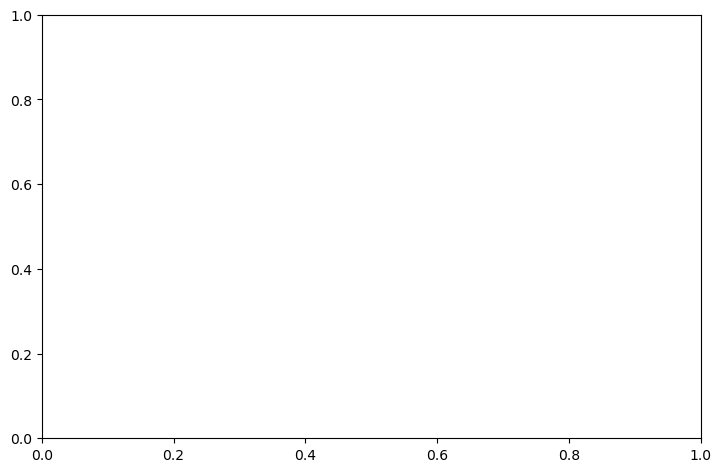

In [187]:
forest = or_table[or_table["Term"] != "Intercept"].copy().sort_values("OR")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ypos = np.arange(len(forest))
x = forest["OR"].to_numpy()
xerr = np.vstack([
    x - forest["Lower95"].to_numpy(),
    forest["Upper95"].to_numpy() - x
])

ax.errorbar(x, ypos, xerr=xerr, fmt="o", capsize=4)
ax.axvline(1, linestyle="--", linewidth=1.2)
ax.set_yticks(ypos)
ax.set_yticklabels(forest["Term"])
ax.set_xscale("log")
ax.set_xlabel("Odds ratio, log scale")
ax.set_title("Exploratory model for CARPOPFL=Y")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_cardiac_ae_logistic_forest.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
print("INTERPRETATION")
for row in forest.itertuples():
    direction = "higher" if row.OR > 1 else "lower"
    sig = "p<0.05" if row.p_value < 0.05 else "p>=0.05"
    print(f"- {row.Term}: OR={row.OR:.2f} (95% CI {row.Lower95:.2f}-{row.Upper95:.2f}); {direction} estimated odds; {sig}.")
print("- These coefficients describe this synthetic realization only.")
print("- A real clinical model would require prespecification, validation, calibration, and governance.")

## 12. Disposition and AE-related discontinuation

In [ ]:
final_disp = final_ds.merge(rand[["USUBJID", "ARM"]], on="USUBJID", how="inner")
disp_table = pd.crosstab(final_disp["DSDECOD"], final_disp["ARM"])
disp_pct = disp_table.div(disp_table.sum(axis=0), axis=1) * 100
disp_pct

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
disp_pct.T.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("Subjects (%)")
ax.set_xlabel("Treatment arm")
ax.set_title("Final disposition by treatment arm")
ax.legend(title="Final disposition", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_final_disposition.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Derived-variable audit table

In [ ]:
audit_table = pd.DataFrame([
    ["AGEGR9", "DM.AGE", "Categorise <18, 18-50, >50", "Category boundaries"],
    ["AGEGR9N", "AGEGR9", "Map categories to 1, 2, 3", "Exact label-to-code mapping"],
    ["TRTSDTM", "EX.EXDOSE, EX.EXTRT, EX.EXSTDTC", "Earliest valid exposure", "Dose validity + chronological sort"],
    ["TRTSTMF", "EX.EXSTDTC", "Flag imputed time components", "Partial-time parsing + provenance"],
    ["ITTFL", "DM.ARM", "Y if ARM populated, else N", "Assessment-specific population rule"],
    ["ABNSBPFL", "VS.VSTESTCD, VSSTRESN, VSSTRESU", "Y if any SYSBP <100 or >=140 mmHg", "Units + repeated records + threshold"],
    ["LSTALVDT", "VS, AE, DS, EX dates", "Maximum qualifying source date", "Date parsing + source hierarchy + joins"],
    ["CARPOPFL", "AE.AESOC", "Y if any CARDIAC DISORDERS", "Case normalization + subject deduplication"]
], columns=["Derived variable", "Source", "Rule", "Primary QC risk"])

audit_table

## 14. Main conclusions and implications

1. **Derivation is not copying.** Each ADSL variable has an explicit source and rule.
2. **One record per subject must be protected.** A merge can run successfully and still duplicate participants.
3. **Missing-time imputation must remain visible.** `TRTSTMF` distinguishes imputed values from observations.
4. **Subject counts and event counts answer different safety questions.**
5. **A flag is a rule-based marker, not automatically a diagnosis.**
6. **`CARPOPFL` identifies a cardiac-AE population; it is not a validated cardiac-risk score.**
7. **`LSTALVDT` is traceability-sensitive** because it combines several domains.
8. **Successful execution does not prove clinical correctness.** Independent QC remains necessary.
9. **Literature benchmarking improves realism but does not turn synthetic data into clinical evidence.**
10. **Exploratory models on synthetic data demonstrate workflow, not medical conclusions.**

### Interview summary

> “I simulated source clinical domains using PubMed-indexed literature as calibration anchors, implemented the assessment-specific ADSL derivations, independently reproduced each critical flag from source records, verified one-record-per-subject integrity, and then analysed the resulting subject-level and event-level data. I kept the distinction between specification-driven programming rules and clinical interpretation explicit throughout.”

## References

- Li C, Liang W, et al. *Sleep and risk of hypertension in general American adults: the National Health and Nutrition Examination Surveys (2015-2018).* J Hypertens. PMID: 36129105. https://doi.org/10.1097/HJH.0000000000003299
- Howick J, Webster R, Kirby N, Hood K. *Rapid overview of systematic reviews of nocebo effects reported by patients taking placebos in clinical trials.* Trials. 2018;19:674. PMID: 30526685. https://doi.org/10.1186/s13063-018-3042-4
- Chacón MR, et al. *Incidence of Placebo Adverse Events in Randomized Clinical Trials of Targeted and Immunotherapy Agents in the Adjuvant Setting.* JAMA Netw Open. PMID: 30646278. https://doi.org/10.1001/jamanetworkopen.2018.5617
- Swain SM, et al. *Cardiac tolerability of pertuzumab plus trastuzumab plus docetaxel in patients with HER2-positive metastatic breast cancer in CLEOPATRA.* Oncologist. 2013. PMID: 23475636. https://doi.org/10.1634/theoncologist.2012-0448
- Siddiqui O. *Statistical methods to analyze adverse events data of randomized clinical trials.* J Biopharm Stat. 2009;19(5):889-899. PMID: 20183450. https://doi.org/10.1080/10543400903105463